<center>

# Applying Video Mining Analytics for Urban Safety and Activity Outbreak Detection in Kenyan Cities

### CSA 806 - Data Mining and Big Data
### Module 9 - Text Mining and Sentiment Analysis

<center>

## Group  Details

This following are group five members who participated in the assignment. 
```
1.  Khaemba Imelda Nasimiyu - ST62/55266/2025  
2. Grace Mwai - ST62/56407/2025  
3. Murangiri Julius Elijah - ST62/56956/2025  
4. Frieze Wandabwa - ST62/55175/2025  
5. Mbarak Abdallah Kumbo - ST62/55566/2025  
6. Seth Makori - ST62/55318/2025  
7. Victor Chiuri Gateru - ST62/80979/2024  
8. Paul Maweu Manthi - ST62/56199/2025  
9. Erick Ngari - ST62/56218/2025  
10. Framul Muriithi - ST62/55824/2025  
11. Kariuki James Kariuki - ST62/55039/2025  
12. Marrion Kiprop Cherop – ST62/80971/2024 

## 1. Introduction

Urban centers in Kenya, particularly cities such as Nairobi, experience challenges related to congestion, crowd control, and public safety. With the increasing availability of surveillance cameras and spread of powerful phones with high quality cameras, video analytics provides an effective way to monitor and analyze public spaces.

This project applies video analytics techniques to analyze activity in a public urban setting with specific analysis of Nairobi night life. The goal is to detect patterns in movement, identify people, and generate insights that can improve urban safety, especially at night.

## 2. Data Collection

To simulate real-world public surveillance, a video of a busy Nairobi street at night was obtained from YouTube using the `yt-dlp` library.

This approach provides:
- Realistic urban activity like movement of pedestrians, vehicles, crowds
- A practical alternative to physical CCTV data collection

In [28]:
#!pip install yt-dlp opencv-python numpy
import sys, os
import yt_dlp
import cv2
sys.stderr = open(os.devnull, 'w')

url = "https://youtu.be/zSDI2Yr5-YQ?si=lVIFeqF-FxPFQIw9"
ydl_opts = {'format': 'mp4', 'outtmpl': 'urban_video.mp4'}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

print("Download complete!")


[youtube] Extracting URL: https://youtu.be/zSDI2Yr5-YQ?si=lVIFeqF-FxPFQIw9
[youtube] zSDI2Yr5-YQ: Downloading webpage


[youtube] zSDI2Yr5-YQ: Downloading android vr player API JSON
[info] zSDI2Yr5-YQ: Downloading 1 format(s): 18
[download] urban_video.mp4 has already been downloaded
[download] 100% of   30.73MiB
Download complete!


## 3. Methodology

This implementation represents a practical video mining pipeline combining segmentation, object detection, and event analysis to extract meaningful insights from urban video data.

## 3.1 Video Loading

The video was loaded using OpenCV (`cv2.VideoCapture`) and processed frame by frame over a defined window of 2 minutes. 

In [22]:

cap = cv2.VideoCapture("urban_video.mp4")

if not cap.isOpened():
    print("Error opening video")
else:
    print("Video loaded successfully")
cap.release()

MAX_SECONDS = 120   # runtime limit in seconds


Video loaded successfully


## 3.2 Video Segmentation using Motion Detection

Video segmentation was done through motion detection by comparing consecutive frames.

The steps undertaken include;
- Computing frame difference
- Converting to grayscale
- Applying Gaussian blur
- Applying thresholding
- Detecting contours

This process identifies areas of movement and segments the video into active regions.

In [23]:
try:
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(img):
        cv2.imshow("Motion Detection", img)

cap = cv2.VideoCapture("urban_video.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
max_frames = int(MAX_SECONDS * fps)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

motion_events = 0
frame_index = 0
motion_per_frame = []

while cap.isOpened() and frame_index < max_frames:
    diff = cv2.absdiff(frame1, frame2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
    dilated = cv2.dilate(thresh, None, iterations=3)

    contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    frame_motion = 0
    for contour in contours:
        if cv2.contourArea(contour) < 1000:
            continue
        motion_events += 1
        frame_motion += 1
        (x, y, w, h) = cv2.boundingRect(contour)
        cv2.rectangle(frame1, (x,y), (x+w, y+h), (0,255,0), 2)

    motion_per_frame.append(frame_motion)
    if frame_index % 10 == 0:  # show every 10th frame
        cv2_imshow(frame1)

    frame1 = frame2
    ret, frame2 = cap.read()
    if not ret:
        break

    frame_index += 1

cap.release()
print("Motion events detected:", motion_events)
print(f"Processed {frame_index} frames (~{frame_index/fps:.2f} seconds)")


Motion events detected: 18829
Processed 3000 frames (~120.00 seconds)


## 3.3 Object Detection

To detect people in the video, Haar Cascade classifiers were used. This included converting frame to grayscale, applying full-body Haar cascade, drawing bounding boxes around detected individuals and then counting detected objects. This allows estimation of pedestrian presence and crowd density.

In [24]:
from collections import Counter

cap = cv2.VideoCapture("urban_video.mp4")
body_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_fullbody.xml')

detections_all = []
frame_index = 0

while cap.isOpened() and frame_index < max_frames:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    bodies = body_cascade.detectMultiScale(gray, 1.1, 3)

    for (x, y, w, h) in bodies:
        cv2.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        detections_all.append({"label": "person", "bbox": (int(x),int(y),int(w),int(h))})

    if frame_index % 10 == 0:
        cv2_imshow(frame)

    frame_index += 1

cap.release()
labels = [d["label"] for d in detections_all]
label_counts = Counter(labels)

print("Object Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")


Object Counts:
person: 1379


## 4. Results and Analysis

## 4.1 Motion Analysis

A total of 18,829 motion events were detected over 2 minutes. Frames with high motion intensity indicate busy and crowded periods.

### 4.1.1 Plot Intensity

A plot was drawn to show periods of high motion intensity.

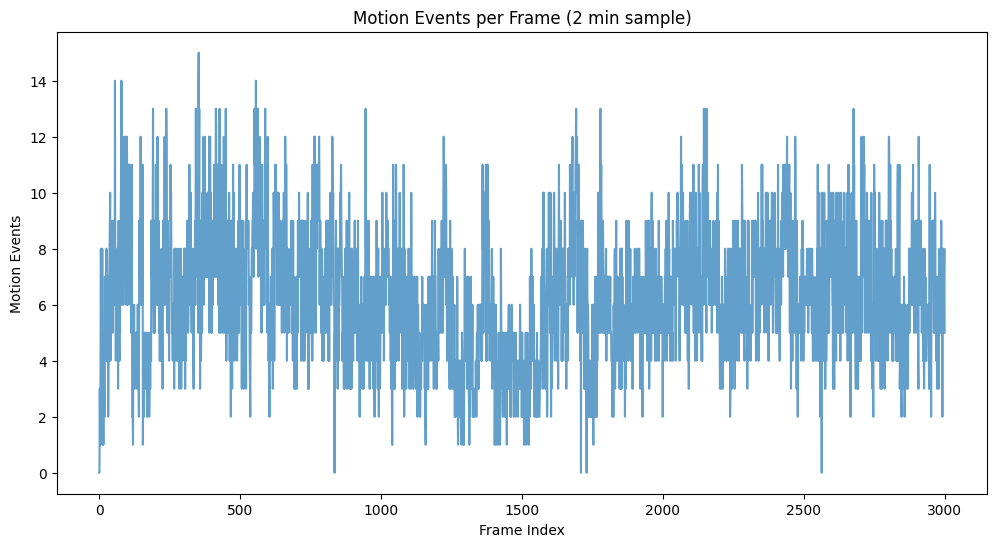

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(motion_per_frame, alpha=0.7)
plt.title("Motion Events per Frame (2 min sample)")
plt.xlabel("Frame Index")
plt.ylabel("Motion Events")
plt.show()



## 4.2 Outbreak Detection

To capture outbreakk dectection, frames with more than 10 motion events were flagged as high-activity periods.

These correspond to:
- Sudden crowd gatherings  
- Traffic congestion  
- Increased pedestrian flow  

### 4.2.1 Saving of Outbreaks Frames
To also enable further analyis, these outbreaks were saved so that they can be used in visualization.

In [26]:

outbreak_folder = "output/outbreaks"
os.makedirs(outbreak_folder, exist_ok=True)

cap = cv2.VideoCapture("urban_video.mp4")
frame_index = 0
while cap.isOpened() and frame_index < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_index < len(motion_per_frame) and motion_per_frame[frame_index] >= 10:
        cv2.imwrite(os.path.join(outbreak_folder, f"outbreak_{frame_index}.jpg"), frame)
    frame_index += 1
cap.release()
print("Outbreak frames saved!")


Outbreak frames saved!


### 4.2.2. Visualization of Outbreaks Frames Dectected


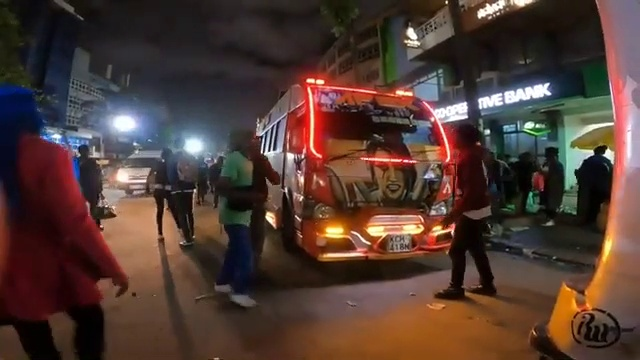
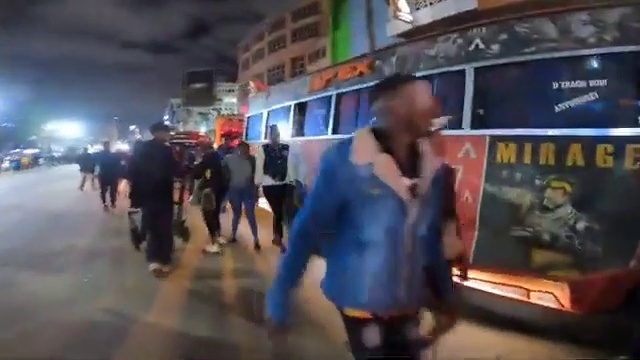
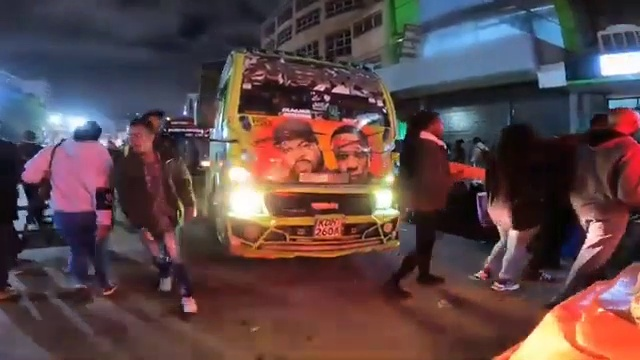
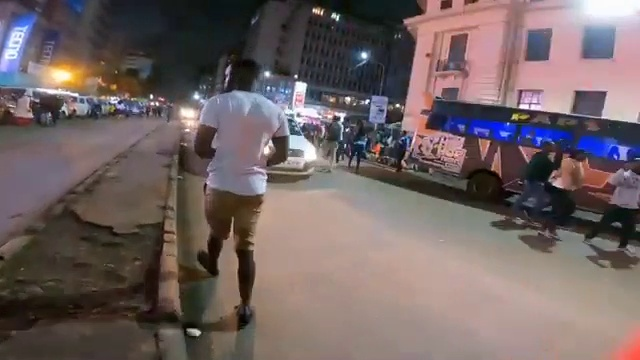
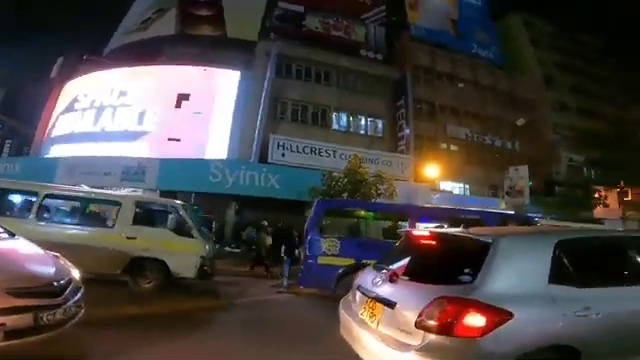
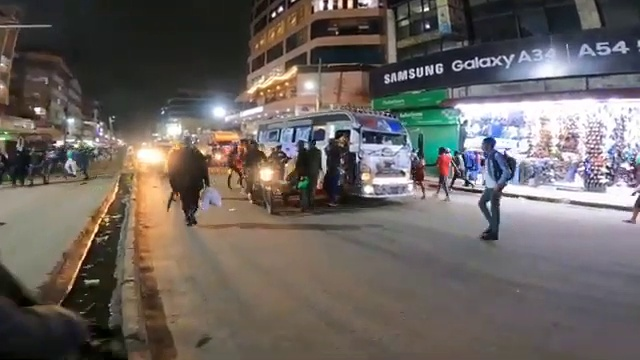
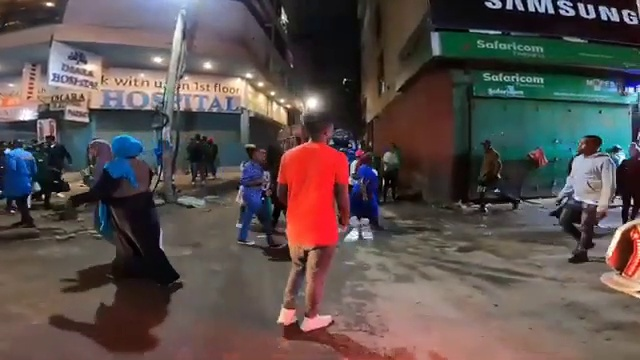
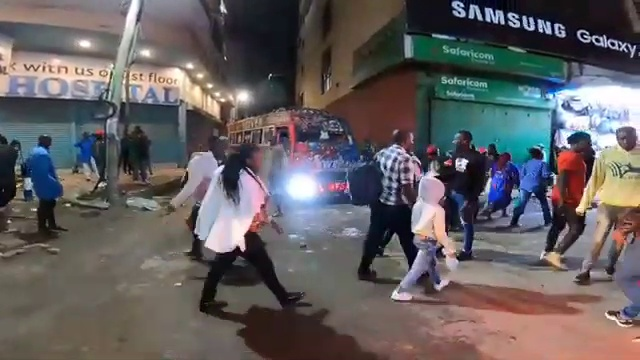
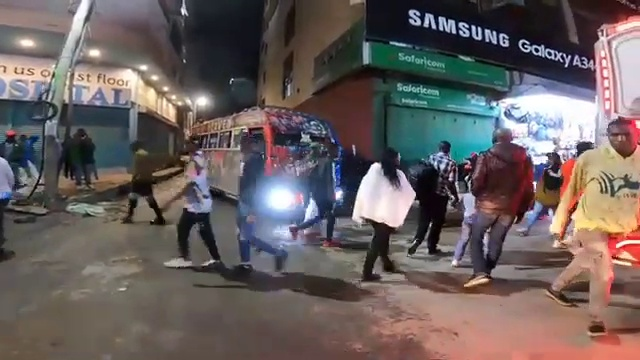
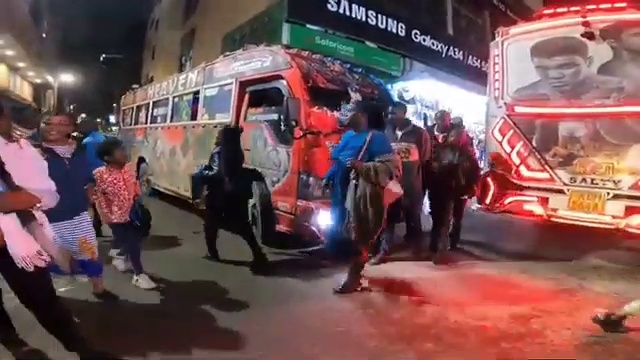

In [29]:
import base64
from IPython.display import HTML

def embed_image(path, width=300):
    """Embed an image as Base64 so it survives HTML export."""
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/jpeg;base64,{data}" width="{width}"/>'

# Example: outbreak gallery
outbreak_frames = [39, 354, 546, 1066, 1689, 1960, 2352, 2431, 2469, 2965]
html_gallery = "<h2>4.2.3 Sampled Outbreak Frames</h2><div align='center'>"

for frame_id in outbreak_frames:
    path = f"output/outbreaks/outbreak_{frame_id}.jpg"
    html_gallery += embed_image(path, width=250)

html_gallery += "</div>"

HTML(html_gallery)


## 4.3 Object Detection Results

A total of 1,379 people detections were recorded in the video section used. This reflected high pedestrian density and active urban movement patterns  

## 5. Insights

The analysis of the video revealed that motion events serve as a reliable indicator of overall activity intensity within the observed environment. Frames with consistently high counts corresponded to crowded or busy areas, while sudden spikes in motion events highlighted unusual occurrences or outbreaks of activity. These outbreaks represent moments of heightened movement that might signal crowd formation, congestion, or other irregular events requiring attention. Object detection further enriched the analysis by quantifying pedestrian presence and density, offering a clearer understanding of how people contributed to the observed activity patterns. Motion tracking and object detection provide complementary perspectives that enable a comprehensive assessment of urban dynamics and potential public safety concerns.


## 6. Actionable Strategies for Urban Safety

Based on the analysis, the following strategies are recommended:

### 6.1 Smart CCTV Monitoring
Deploy AI-enabled CCTV systems to automatically detect unusual activity and alert authorities in real time.

### 6.2 Crowd Density Management
Use video analytics to monitor crowded areas and prevent overcrowding in areas markets, transport hubs, public events, sport event, church and other social events.

### 6.3 Traffic Control Optimization
Integrate object detection with traffic systems to predict congestion improve signal timing and manage pedestrian crossings  

### 6.4 Real-Time Alert Systems
Develop systems that trigger alerts when abnormal motion patterns are detected, enabling faster emergency response.

### 6.5 Integration with Emergency Services
Link video analytics systems with police and emergency services to ensure rapid intervention in critical situations.


## 7. Conclusion

This project demonstrates how video analytics techniques such as motion-based segmentation and object detection can be applied to improve public safety in Kenyan cities. By identifying patterns in movement and detecting human activity, authorities can make informed decisions that enhance urban security and efficiency. Future improvements will include the use of advanced deep learning models such as YOLO, CNNs among others for more accurate object detection.